# Basic SD 1.5 Inpainting Image/Mask Test

This notebook intentionally ignores the rest of the repo.

It tests only:

- one selected source image;
- one selected mask image, or a generated mask for image-only datasets;
- the base `stable-diffusion-v1-5/stable-diffusion-inpainting` model;
- optionally, one selected LoRA adapter.

White mask pixels are the area Stable Diffusion repaints.


In [35]:
from pathlib import Path
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
from diffusers import DPMSolverMultistepScheduler, StableDiffusionInpaintPipeline
from PIL import Image, ImageDraw, ImageOps


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "backend").exists() and (candidate / "frontend").exists() and (candidate / "notebooks").exists():
            return candidate
    raise RuntimeError("Could not find repo root. Run this notebook from the repo or notebooks directory.")


REPO_ROOT = find_repo_root()
OUTPUT_DIR = REPO_ROOT / "notebooks" / "outputs" / "notebook_baseline_inpaint"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RUN_ID = time.strftime("%Y%m%d_%H%M%S")

MODEL_ID = "stable-diffusion-v1-5/stable-diffusion-inpainting"

# Change this to choose the image/mask source dataset.
DATASET_NAME = "small_house_set"
DATASET_DIR = REPO_ROOT / "datasets" / DATASET_NAME

# Explicit test image/mask. Set these to None to use DATASET_DIR metadata/test_mask/matching masks automatically.
IMAGE_PATH = REPO_ROOT / "test_images" / "satelite-image.png"
MASK_PATH = REPO_ROOT / "test_images" / "satelite-mask.png"

# If the selected dataset has images but no mask, use a simple generated mask.
GENERATE_MASK_IF_MISSING = True

# Change only this value to test a different LoRA. Examples:
#   None
#   "lora_trees/pytorch_lora_weights.safetensors"
#   "lora_small_house_set_sd15_inpaint"
#   "lora_small_tree_set_sd15_inpaint/pytorch_lora_weights.safetensors"
#   "pytorch_lora_weights.safetensors"
LORA_TO_TEST = "lora_small_house_set_sd15_inpaint"
LORA_SCALE = 0.55
LORA_SEARCH_ROOTS = [
    REPO_ROOT / "notebooks" / "outputs",
    REPO_ROOT / "outputs",
    REPO_ROOT / "backend" / "models",
]

# Stable Diffusion inpainting expects white pixels to be repainted and black pixels to be preserved.
INVERT_MASK = False

# Keep True if the model already exists in your Hugging Face cache. Set False only for first download.
LOCAL_FILES_ONLY = True

PROMPT = "small patch of trees, in the style of a satellite image, with a lot of texture and detail"
NEGATIVE_PROMPT = "low quality, blurry, bad anatomy, disfigured, deformed, extra limbs, close up, b&w, weird colors"

# Set to an integer for repeatable results. Set to None for a new result each run.
SEED = None
RUN_SEED = int(SEED) if SEED is not None else int(time.time()) % 2_147_483_647

RESOLUTION = 512
NUM_INFERENCE_STEPS = 40
GUIDANCE_SCALE = 5.5
STRENGTH = 0.9

print("repo root:", REPO_ROOT)
print("dataset:", DATASET_DIR)
print("output:", OUTPUT_DIR)
print("run id:", RUN_ID)
print("seed:", RUN_SEED)


repo root: C:\Users\neman\Documents\UVPython\inpainting
dataset: C:\Users\neman\Documents\UVPython\inpainting\datasets\small_house_set
output: C:\Users\neman\Documents\UVPython\inpainting\notebooks\outputs\notebook_baseline_inpaint
run id: 20260526_053535
seed: 1779766535


## Load And Inspect Image/Mask

This cell checks the basics before any model is loaded. If the mask is wrong here, the model result will also be wrong.

Important: white mask pixels are the area Stable Diffusion will repaint.

In [36]:
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".webp", ".tif", ".tiff"}


def resolve_dataset_path(dataset_dir: Path, value: str | Path | None) -> Path | None:
    if value is None:
        return None
    path = Path(value)
    return path if path.is_absolute() else dataset_dir / path


def first_image_file(dataset_dir: Path) -> Path | None:
    for search_dir in (dataset_dir / "images", dataset_dir):
        if not search_dir.exists():
            continue
        for path in sorted(search_dir.iterdir()):
            if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
                return path
    return None


def test_mask_pair(dataset_dir: Path) -> tuple[Path, Path] | None:
    image_path = dataset_dir / "test_mask" / "image.png"
    mask_path = dataset_dir / "test_mask" / "mask.png"
    if image_path.exists() and mask_path.exists():
        return image_path, mask_path
    return None


def matching_mask_path(dataset_dir: Path, image_path: Path) -> Path | None:
    for mask_dir_name in ("masks", "mask"):
        mask_path = dataset_dir / mask_dir_name / f"{image_path.stem}_mask.png"
        if mask_path.exists():
            return mask_path
    return None


def generated_center_mask(size: tuple[int, int]) -> Image.Image:
    width, height = size
    mask = Image.new("L", size, 0)
    draw = ImageDraw.Draw(mask)
    margin_x = max(16, width // 4)
    margin_y = max(16, height // 4)
    draw.ellipse((margin_x, margin_y, width - margin_x, height - margin_y), fill=255)
    return mask


def first_dataset_pair(dataset_dir: Path) -> tuple[Path, Path | None]:
    explicit_image = resolve_dataset_path(dataset_dir, IMAGE_PATH)
    explicit_mask = resolve_dataset_path(dataset_dir, MASK_PATH)
    if explicit_image is not None:
        if explicit_mask is None:
            explicit_mask = matching_mask_path(dataset_dir, explicit_image)
        return explicit_image, explicit_mask

    pair = test_mask_pair(dataset_dir)
    if pair is not None:
        return pair

    metadata_path = dataset_dir / "metadata.jsonl"
    first_metadata_image = None
    if metadata_path.exists():
        for line in metadata_path.read_text(encoding="utf-8").splitlines():
            if not line.strip():
                continue
            row = json.loads(line)
            first_metadata_image = resolve_dataset_path(dataset_dir, row.get("image"))
            metadata_mask = resolve_dataset_path(dataset_dir, row.get("mask"))
            if first_metadata_image is not None and metadata_mask is not None:
                return first_metadata_image, metadata_mask
            break

    fallback_image = first_metadata_image or first_image_file(dataset_dir)
    if fallback_image is not None:
        return fallback_image, matching_mask_path(dataset_dir, fallback_image)

    raise FileNotFoundError(
        f"No image/mask pair found in {dataset_dir}. Set IMAGE_PATH and MASK_PATH, "
        "or provide metadata.jsonl/test_mask files."
    )


image_path, mask_path = first_dataset_pair(DATASET_DIR)

if not image_path.exists():
    raise FileNotFoundError(f"Image not found: {image_path}")
if mask_path is not None and not mask_path.exists():
    raise FileNotFoundError(f"Mask not found: {mask_path}")

raw_image = Image.open(image_path)
if mask_path is None:
    if not GENERATE_MASK_IF_MISSING:
        raise FileNotFoundError("No mask was found. Set MASK_PATH or enable GENERATE_MASK_IF_MISSING.")
    raw_mask = generated_center_mask(raw_image.size)
    mask_label = "generated center mask"
else:
    raw_mask = Image.open(mask_path)
    mask_label = str(mask_path)

print("image path:", image_path)
print("mask path: ", mask_label)
print("image mode/size:", raw_image.mode, raw_image.size)
print("mask mode/size: ", raw_mask.mode, raw_mask.size)

if raw_image.size != raw_mask.size:
    print("WARNING: image and mask have different sizes. The mask will be resized to match the image before inference.")


image path: C:\Users\neman\Documents\UVPython\inpainting\test_images\satelite-image.png
mask path:  C:\Users\neman\Documents\UVPython\inpainting\test_images\satelite-mask.png
image mode/size: RGBA (1734, 1401)
mask mode/size:  RGBA (1734, 1401)


In [37]:
image = raw_image.convert("RGB")
mask = raw_mask.convert("L")

if mask.size != image.size:
    mask = mask.resize(image.size, Image.Resampling.NEAREST)

if INVERT_MASK:
    mask = ImageOps.invert(mask)

# Force a binary mask so semi-transparent or antialiased edges do not hide what is being tested.
mask = mask.point(lambda value: 255 if value > 127 else 0)

mask_array = np.asarray(mask)
coverage = float((mask_array > 0).mean())
unique_values = np.unique(mask_array)

print("binary mask values:", unique_values.tolist())
print(f"white/inpaint coverage: {coverage:.4%}")

if coverage == 0:
    raise ValueError("Mask has no white pixels. Nothing will be inpainted.")
if coverage == 1:
    raise ValueError("Mask is fully white. The entire image will be replaced.")

# Resize both together for a simple full-frame model test.
test_image = image.resize((RESOLUTION, RESOLUTION), Image.Resampling.BILINEAR)
test_mask = mask.resize((RESOLUTION, RESOLUTION), Image.Resampling.NEAREST)
test_mask = test_mask.point(lambda value: 255 if value > 127 else 0)

preserved_preview = Image.composite(test_image, Image.new("RGB", test_image.size, (0, 0, 0)), test_mask)
repaint_preview = Image.composite(Image.new("RGB", test_image.size, (255, 255, 255)), test_image, test_mask)

test_image.save(OUTPUT_DIR / "input_512.png")
test_mask.save(OUTPUT_DIR / "mask_512_white_repaints.png")
preserved_preview.save(OUTPUT_DIR / "preserved_area_preview.png")
repaint_preview.save(OUTPUT_DIR / "repaint_area_preview.png")

binary mask values: [0, 255]
white/inpaint coverage: 4.0280%


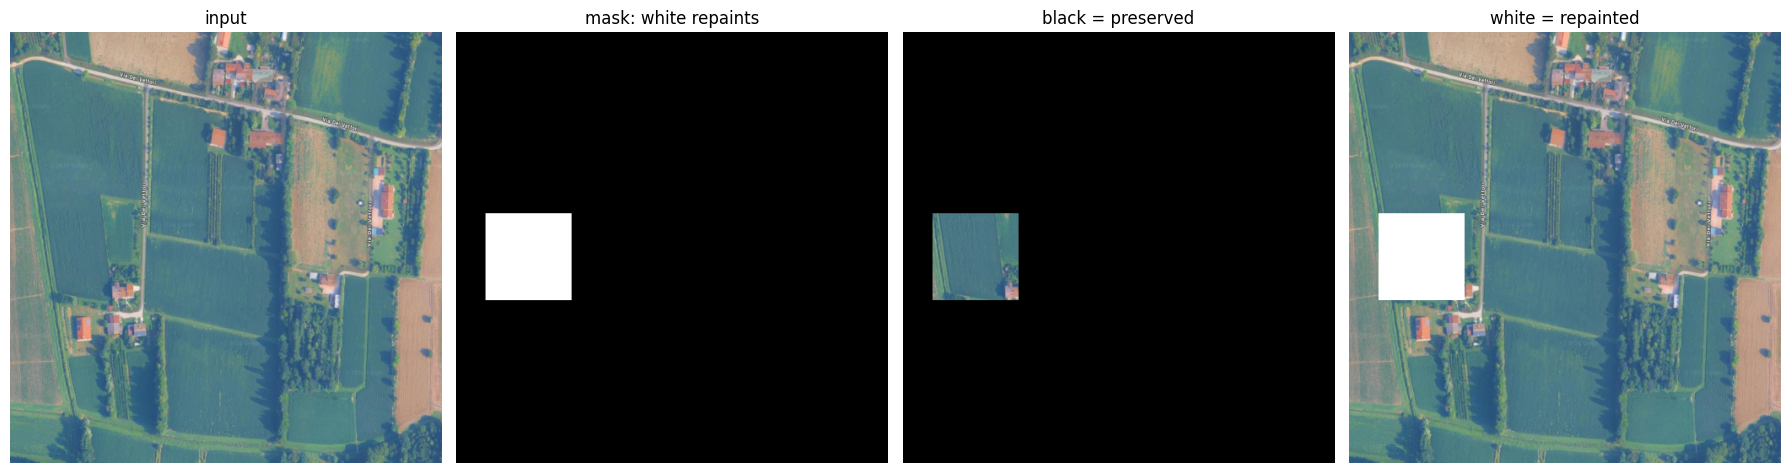

In [38]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
items = [
    ("input", test_image, None),
    ("mask: white repaints", test_mask, "gray"),
    ("black = preserved", preserved_preview, None),
    ("white = repainted", repaint_preview, None),
]

for axis, (title, item, cmap) in zip(axes, items):
    axis.imshow(item, cmap=cmap)
    axis.set_title(title)
    axis.axis("off")

plt.tight_layout()

## Load Only The Base Inpainting Model

This must report `unet input channels: 9`. If it reports 4, the non-inpainting model was loaded.

In [39]:
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

pipe = StableDiffusionInpaintPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype,
    safety_checker=None,
    local_files_only=LOCAL_FILES_ONLY,
    use_safetensors=False,
).to(device)

pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    pipe.scheduler.config,
    algorithm_type="dpmsolver++",
    use_karras_sigmas=True,
)

if device == "cuda":
    pipe.enable_attention_slicing()
    pipe.vae.enable_slicing()

pipe.set_progress_bar_config(disable=False)

print("device:", device)
print("pipeline:", pipe.__class__.__name__)
print("unet input channels:", pipe.unet.config.in_channels)

if int(pipe.unet.config.in_channels) != 9:
    raise RuntimeError("Wrong model loaded. Stable Diffusion inpainting must use a 9-channel UNet.")

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: C:\Users\neman\.cache\huggingface\hub\models--stable-diffusion-v1-5--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_inpaint.StableDiffusionInpaintPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analy

device: cuda
pipeline: StableDiffusionInpaintPipeline
unet input channels: 9


## Run Inpainting

  0%|          | 0/36 [00:00<?, ?it/s]

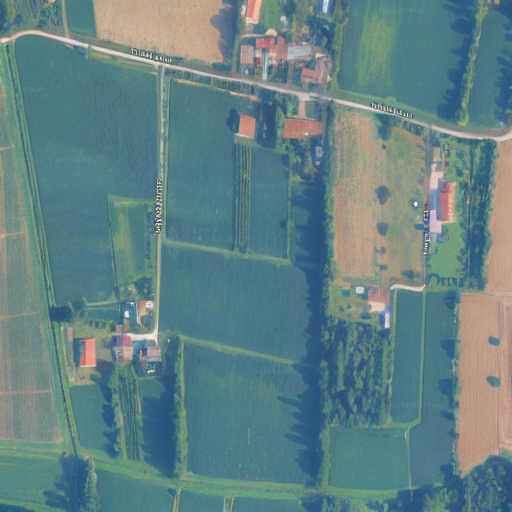

In [40]:
generator = torch.Generator(device=device).manual_seed(RUN_SEED)

result = pipe(
    prompt=PROMPT,
    negative_prompt=NEGATIVE_PROMPT,
    image=test_image,
    mask_image=test_mask,
    height=RESOLUTION,
    width=RESOLUTION,
    strength=STRENGTH,
    num_inference_steps=NUM_INFERENCE_STEPS,
    guidance_scale=GUIDANCE_SCALE,
    generator=generator,
).images[0]

result.save(OUTPUT_DIR / "latest_base_result.png")
result.save(OUTPUT_DIR / f"base_result_{RUN_ID}.png")
result

saved outputs to: C:\Users\neman\Documents\UVPython\inpainting\notebooks\outputs\notebook_baseline_inpaint


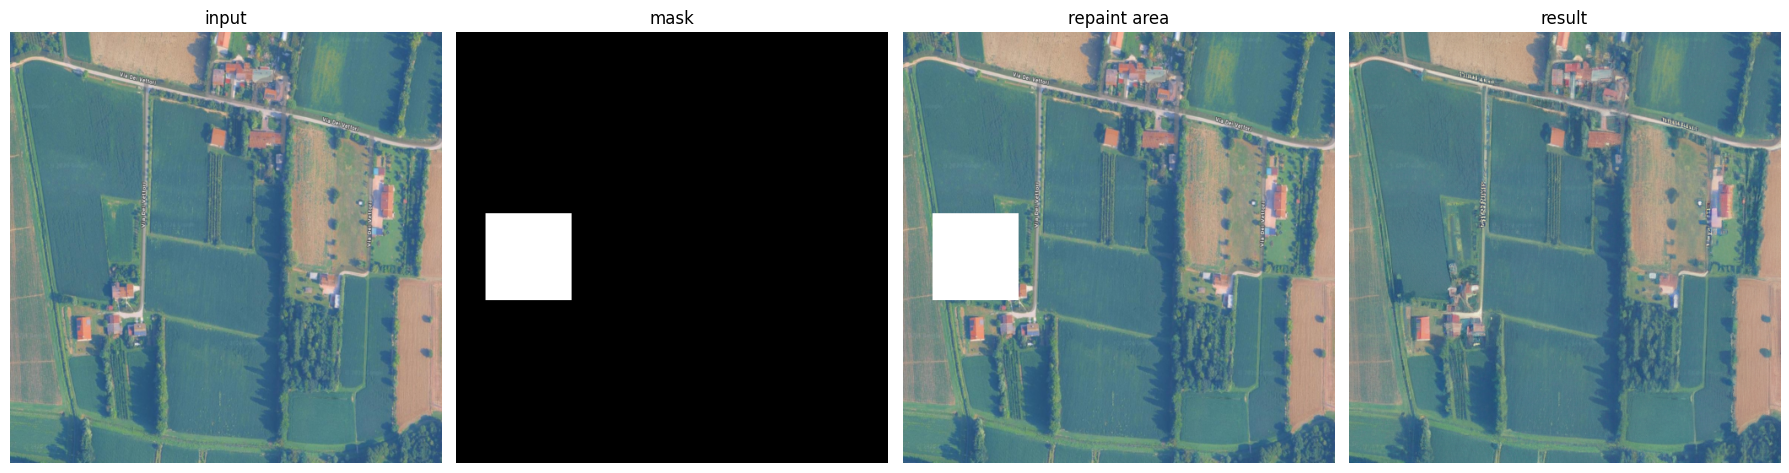

In [29]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
items = [
    ("input", test_image, None),
    ("mask", test_mask, "gray"),
    ("repaint area", repaint_preview, None),
    ("result", result, None),
]

for axis, (title, item, cmap) in zip(axes, items):
    axis.imshow(item, cmap=cmap)
    axis.set_title(title)
    axis.axis("off")

plt.tight_layout()
print("saved outputs to:", OUTPUT_DIR)

## Optional LoRA Test

Set `LORA_TO_TEST` in the first code cell to choose an adapter. It can be a folder, a relative path under `notebooks/outputs`, `outputs`, or `backend/models`, or a single `.safetensors` filename to search for.

The base image, mask, prompt, seed, and inference settings stay identical so the LoRA comparison is direct.


In [30]:
def lora_candidates(selection: str | Path):
    selected = Path(selection)
    if selected.is_absolute():
        yield selected
        return

    yield REPO_ROOT / selected
    for root in LORA_SEARCH_ROOTS:
        yield root / selected

    if len(selected.parts) == 1:
        for root in LORA_SEARCH_ROOTS:
            if root.exists():
                yield from sorted(root.glob(f"*/{selected.name}"))


def resolve_lora(selection: str | Path | None) -> Path | None:
    if selection is None or str(selection).strip() == "":
        return None

    checked = []
    for candidate in lora_candidates(selection):
        checked.append(candidate)
        if candidate.is_dir() and (candidate / "pytorch_lora_weights.safetensors").exists():
            return candidate
        if candidate.is_file():
            return candidate

    formatted = "\n".join(f"  - {path}" for path in checked)
    raise FileNotFoundError(f"Could not find LoRA selection {selection!r}. Checked:\n{formatted}")


SELECTED_LORA_PATH = resolve_lora(LORA_TO_TEST)
print("LoRA selection:", LORA_TO_TEST)
print("Resolved LoRA:", SELECTED_LORA_PATH if SELECTED_LORA_PATH is not None else "skipped")
print("LoRA scale:", LORA_SCALE)


LoRA selection: lora_small_house_set_sd15_inpaint
Resolved LoRA: C:\Users\neman\Documents\UVPython\inpainting\notebooks\outputs\lora_small_house_set_sd15_inpaint
LoRA scale: 0.55


In [31]:
def load_base_pipe_with_optional_lora(lora_path=None, lora_scale=1.0):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    dtype = torch.float16 if device == "cuda" else torch.float32

    pipe = StableDiffusionInpaintPipeline.from_pretrained(
        MODEL_ID,
        torch_dtype=dtype,
        safety_checker=None,
        local_files_only=LOCAL_FILES_ONLY,
        use_safetensors=False,
    ).to(device)

    pipe.scheduler = DPMSolverMultistepScheduler.from_config(
        pipe.scheduler.config,
        algorithm_type="dpmsolver++",
        use_karras_sigmas=True,
    )

    if int(pipe.unet.config.in_channels) != 9:
        raise RuntimeError("Wrong model loaded. Stable Diffusion inpainting must use a 9-channel UNet.")

    if lora_path is not None:
        lora_path = Path(lora_path)
        if lora_path.is_dir():
            pipe.load_lora_weights(str(lora_path), adapter_name="selected_lora")
        else:
            pipe.load_lora_weights(str(lora_path.parent), weight_name=lora_path.name, adapter_name="selected_lora")

        pipe.enable_lora()
        if hasattr(pipe, "set_adapters"):
            pipe.set_adapters(["selected_lora"], adapter_weights=[lora_scale])

    if device == "cuda":
        pipe.enable_attention_slicing()
        pipe.vae.enable_slicing()

    pipe.set_progress_bar_config(disable=False)
    return pipe, device


if SELECTED_LORA_PATH is None:
    lora_pipe = None
    lora_device = None
    print("No LoRA selected. Set LORA_TO_TEST in the first cell to run this section.")
else:
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    lora_pipe, lora_device = load_base_pipe_with_optional_lora(SELECTED_LORA_PATH, LORA_SCALE)
    print("device:", lora_device)
    print("pipeline:", lora_pipe.__class__.__name__)
    print("unet input channels:", lora_pipe.unet.config.in_channels)


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: C:\Users\neman\.cache\huggingface\hub\models--stable-diffusion-v1-5--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_inpaint.StableDiffusionInpaintPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analy

device: cuda
pipeline: StableDiffusionInpaintPipeline
unet input channels: 9


  0%|          | 0/36 [00:00<?, ?it/s]

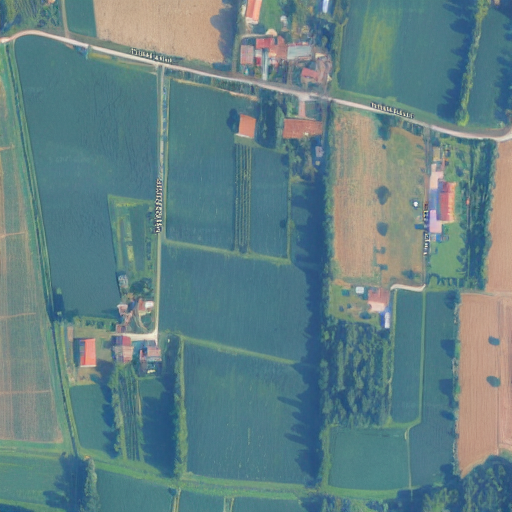

In [32]:
if lora_pipe is None:
    lora_result = None
    print("Skipped LoRA inference.")
else:
    lora_generator = torch.Generator(device=lora_device).manual_seed(RUN_SEED)

    lora_result = lora_pipe(
        prompt=PROMPT,
        negative_prompt=NEGATIVE_PROMPT,
        image=test_image,
        mask_image=test_mask,
        height=RESOLUTION,
        width=RESOLUTION,
        strength=STRENGTH,
        num_inference_steps=NUM_INFERENCE_STEPS,
        guidance_scale=GUIDANCE_SCALE,
        generator=lora_generator,
    ).images[0]

    lora_result.save(OUTPUT_DIR / "latest_lora_result.png")
    lora_result.save(OUTPUT_DIR / f"lora_result_{RUN_ID}.png")

lora_result


base vs lora mean abs diff: 0.1153246561686198
saved latest LoRA result to: C:\Users\neman\Documents\UVPython\inpainting\notebooks\outputs\notebook_baseline_inpaint\latest_lora_result.png
saved run LoRA result to: C:\Users\neman\Documents\UVPython\inpainting\notebooks\outputs\notebook_baseline_inpaint\lora_result_20260526_053231.png


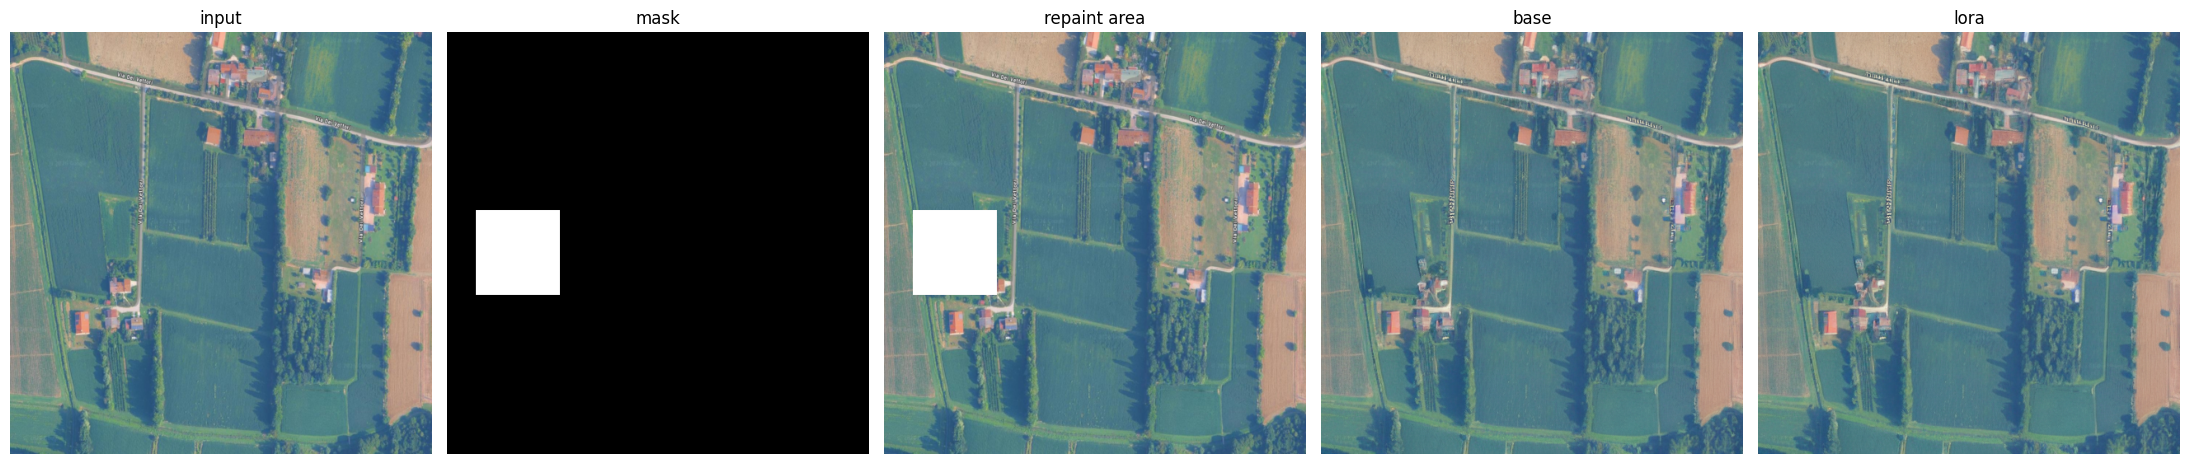

In [33]:
if lora_result is None:
    print("No LoRA result to compare.")
else:
    fig, axes = plt.subplots(1, 5, figsize=(22, 5))
    items = [
        ("input", test_image, None),
        ("mask", test_mask, "gray"),
        ("repaint area", repaint_preview, None),
        ("base", result, None),
        ("lora", lora_result, None),
    ]

    for axis, (title, item, cmap) in zip(axes, items):
        axis.imshow(item, cmap=cmap)
        axis.set_title(title)
        axis.axis("off")

    plt.tight_layout()
    base_array = np.asarray(result.convert("RGB"), dtype=np.int16)
    lora_array = np.asarray(lora_result.convert("RGB"), dtype=np.int16)
    print("base vs lora mean abs diff:", float(np.abs(base_array - lora_array).mean()))
    print("saved latest LoRA result to:", OUTPUT_DIR / "latest_lora_result.png")
    print("saved run LoRA result to:", OUTPUT_DIR / f"lora_result_{RUN_ID}.png")


## Potential problems, if results look wrong anywhere in the code.

Check these before changing any app code:

- If the wrong area changes, toggle `INVERT_MASK` and rerun from the inspection cells.
- If the mask coverage is tiny or huge, the mask image itself is probably wrong.
- If the source image and mask sizes differ, verify they are meant to align before resizing.
- If the image looks stretched, the source is not square and this simple test resized it to 512 x 512. 
- If the base model works here, the issue is probably in the app path rather than Stable Diffusion itself.
